# Data set wisconsin Breast Cancer
é um dataser csasico com features numericas. o objetivo é classificar tumores como malignos ou benignos.


# Preparar os dados
primeros carregamos o dataset, dividindo em conjunto de treino e validacao, e normalizamos as features

In [ ]:
%pip install tensorflow
%pip install git+https://github.com/tensorflow/docs

  Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl.metadata (4.6 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.11.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached ml_dtypes-0.5.3-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.17.0-cp313-cp313-win_amd64.whl.metadata (34 kB)
Using cached tensorflo

  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs 'C:\Users\marco\AppData\Local\Temp\pip-req-build-l_9hsne2'
  DEPRECATION: Building 'tensorflow-docs' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'tensorflow-docs'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as pyplot

from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X, y = data.data, data.target
y = y.reshape(-1, 1)

# Divisão em treino e validação
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Criação de tf.data.Dataset
BATCH_SIZE = 32
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train)).batch(BATCH_SIZE)
validate_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

FEATURES = X_train.shape[1]

treinamos modelos de capacidade crescente para observar como a validacao se comporta

In [11]:
def get_optimizer():
  return tf.keras.optimizers.Adam(0.001)

def get_callbacks(name):
  return [
    tfdocs.modeling.EpochDots(),
    tf.keras.callbacks.EarlyStopping(monitor='val_binary_crossentropy', patience=50), # Paciência menor para datasets pequenos
  ]

def compile_and_fit(model, name, optimizer=None, max_epochs=500):
  if optimizer is None:
    optimizer = get_optimizer()
  model.compile(optimizer=optimizer,
                loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                metrics=[
                  tf.keras.metrics.BinaryCrossentropy(
                      from_logits=True, name='binary_crossentropy'),
                  'accuracy'])
  history = model.fit(
    train_ds,
    epochs=max_epochs,
    validation_data=validate_ds,
    callbacks=get_callbacks(name),
    verbose=0)
  return history

# Modelos de diferentes tamanhos
tiny_model = tf.keras.Sequential([
    layers.Dense(16, activation='elu', input_shape=(FEATURES,)),
    layers.Dense(1)
])

small_model = tf.keras.Sequential([
    layers.Dense(16, activation='elu', input_shape=(FEATURES,)),
    layers.Dense(16, activation='elu'),
    layers.Dense(1)
])

large_model = tf.keras.Sequential([
    layers.Dense(512, activation='elu', input_shape=(FEATURES,)),
    layers.Dense(512, activation='elu'),
    layers.Dense(512, activation='elu'),
    layers.Dense(1)
])

# Treinamento
size_histories = {}
size_histories['Tiny'] = compile_and_fit(tiny_model, 'sizes/Tiny')
size_histories['Small'] = compile_and_fit(small_model, 'sizes/Small')
size_histories['Large'] = compile_and_fit(large_model, 'sizes/Large')

c:\Users\marco\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch: 0, accuracy:0.5912,  binary_crossentropy:0.5374,  loss:0.5374,  val_accuracy:0.7632,  val_binary_crossentropy:0.4140,  val_loss:0.4140,  
....................................................................................................
Epoch: 100, accuracy:0.9890,  binary_crossentropy:0.0321,  loss:0.0321,  val_accuracy:0.9825,  val_binary_crossentropy:0.0612,  val_loss:0.0612,  
.................
Epoch: 0, accuracy:0.6440,  binary_crossentropy:0.5249,  loss:0.5249,  val_accuracy:0.8509,  val_binary_crossentropy:0.3787,  val_loss:0.3787,  
..........................................................................
Epoch: 0, accuracy:0.9033,  binary_crossentropy:0.1703,  loss:0.1703,  val_accuracy:0.9825,  val_binary_crossentropy:0.0729,  val_loss:0.0729,  
............................................................

quadno plotamos, da pra observar que o modelo 'large'começa a superajustar, sua perda de treinamento continua a cair enquanto a perda de validacao estafna e comeca a subir. o modelo 'tiny', mostra cuvas de treinamento e validacao que permanecem proximas, que mostra que tem uma boa generalização.

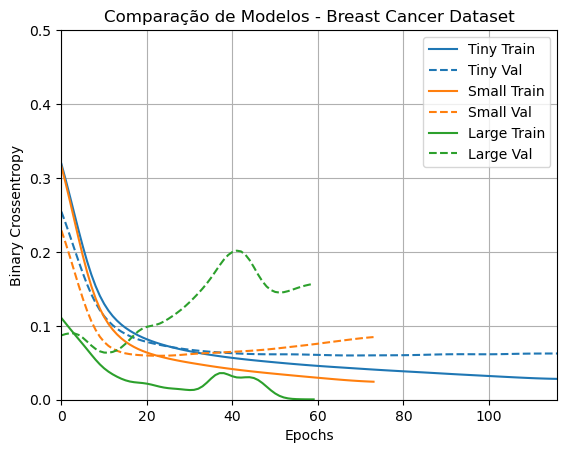

In [12]:
# Código para plotar os resultados
if plotter:
    plotter.plot(size_histories)
    plt.ylim([0, 0.5])
    plt.title("Comparação de Modelos - Breast Cancer Dataset")
    plt.show()

agora aplicando o L2 e dropout ao large model.

In [14]:
regularizer_histories = {}
regularizer_histories['Tiny'] = size_histories['Tiny']
regularizer_histories['Large'] = size_histories['Large']


l2_model = tf.keras.Sequential([
    layers.Dense(512, activation='elu', kernel_regularizer = regularizers.l2(0.001), input_shape=(FEATURES,)),
    layers.Dense(512, activation='elu', kernel_regularizer = regularizers.l2(0.001)),
    layers.Dense(512, activation='elu', kernel_regularizer = regularizers.l2(0.001)),
    layers.Dense(1)
])
regularizer_histories['L2'] = compile_and_fit(l2_model, "regularizers/l2")


dropout_model = tf.keras.Sequential([
    layers.Dense(512, activation='elu', input_shape=(FEATURES,)),
    layers.Dropout(0.5),
    layers.Dense(512, activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(512, activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(1)
])

regularizer_histories['Dropout'] = compile_and_fit(dropout_model, "regularizers/Dropout")


c:\Users\marco\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch: 0, accuracy:0.9143,  binary_crossentropy:0.1834,  loss:1.2369,  val_accuracy:0.9649,  val_binary_crossentropy:0.1005,  val_loss:1.1098,  
.......................................................
Epoch: 0, accuracy:0.8989,  binary_crossentropy:0.2055,  loss:0.2055,  val_accuracy:0.9825,  val_binary_crossentropy:0.0562,  val_loss:0.0562,  
................................................................

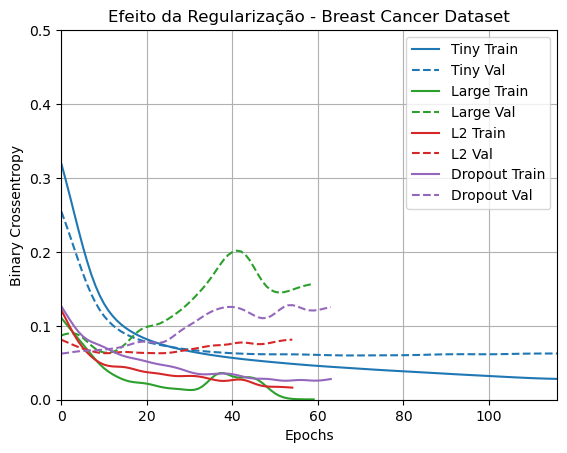

In [15]:
if plotter:
    plotter.plot(regularizer_histories)
    plt.ylim([0, 0.5])
    plt.title("Efeito da Regularização - Breast Cancer Dataset")
    plt.show()

como da pra ver no grafico as tecnicas de relugaricação controlam o overfiting de forma eficaz!!O modelo 'large' com o l2 ou dropout mostra uma perda de validacao muito menor e mais estavel, competindo diretamento com o desempenho do modelo 'Tiny', mesmo tendo uma capacidade muito maior

# Spambase dataset
esse dataset tem features extraidas de email para classificalos como spam ou nao.
tem 57 features numericas e 4601 amostras

Preparando os dados (é parecido com o primeiro)

In [27]:
caminhho = r'C:\Users\marco\OneDrive\Documentos\Faculdade 2025.1\Redes Neutais\dl-2025-1\tasks\task-08-overfit and underfit\spambase.data.csv'


try:
    spam_df = pd.read_csv(caminhho, header=None)
    X = spam_df.iloc[:, :-1].values
    y = spam_df.iloc[:, -1].values
    y = y.reshape(-1,1)
except FileNotFoundError:
    print("Arquivo spambase.data não encontrado. Pulando Experimento 2.")
    X, y = (None, None)


if X is not None:
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    BATCH_SIZE = 128
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train)).batch(BATCH_SIZE)
    validate_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

    FEATURES = X_train.shape[1]

agora repetindo o msm processo de treinar os modelos de diferentes tamanhos e dps aplicar a regularização

In [28]:
if X is not None:
    
    size_histories_spam = {}
    tiny_model_spam = tf.keras.Sequential([
        layers.Dense(16, activation='elu', input_shape=(FEATURES,)),
        layers.Dense(1)
    ]) 
    small_model_spam = tf.keras.Sequential([
        layers.Dense(16, activation='elu', input_shape=(FEATURES,)),
        layers.Dense(16, activation='elu'),
        layers.Dense(1)

    ]) 
    large_model_spam = tf.keras.Sequential([
        layers.Dense(512, activation='elu', input_shape=(FEATURES,)),
        layers.Dense(512, activation='elu'),
        layers.Dense(512, activation='elu'),
        layers.Dense(1)
        
    ])

    size_histories_spam['Tiny'] = compile_and_fit(tiny_model_spam, 'spam/sizes/Tiny')
    size_histories_spam['Small'] = compile_and_fit(small_model_spam, 'spam/sizes/Small')
    size_histories_spam['Large'] = compile_and_fit(large_model_spam, 'spam/sizes/Large')

c:\Users\marco\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch: 0, accuracy:0.5652,  binary_crossentropy:0.8296,  loss:0.8296,  val_accuracy:0.6688,  val_binary_crossentropy:0.6770,  val_loss:0.6770,  
....................................................................................................
Epoch: 100, accuracy:0.9495,  binary_crossentropy:0.1288,  loss:0.1288,  val_accuracy:0.9381,  val_binary_crossentropy:0.1571,  val_loss:0.1571,  
......................................................
Epoch: 0, accuracy:0.7008,  binary_crossentropy:0.5765,  loss:0.5765,  val_accuracy:0.7883,  val_binary_crossentropy:0.4433,  val_loss:0.4433,  
..................................................................................................
Epoch: 0, accuracy:0.8970,  binary_crossentropy:0.2938,  loss:0.2938,  val_accuracy:0.9131,  val_binary_crossentropy:0.2268,  val_loss:0.2268,  
.................................................................

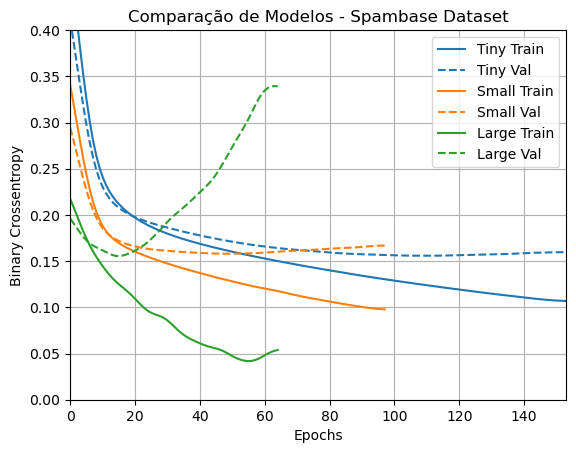

In [30]:
# Plot
if plotter:
    plotter.plot(size_histories_spam)
    plt.ylim([0, 0.4])
    plt.title("Comparação de Modelos - Spambase Dataset")
    plt.show()

   

In [31]:
regularizer_histories_spam = {}
regularizer_histories_spam['Tiny'] = size_histories_spam['Tiny']
regularizer_histories_spam['Large'] = size_histories_spam['Large']
    
l2_model_spam = tf.keras.Sequential([
    layers.Dense(512, activation='elu', kernel_regularizer = regularizers.l2(0.001), input_shape=(FEATURES,)),
    layers.Dense(512, activation='elu', kernel_regularizer = regularizers.l2(0.001)),
    layers.Dense(512, activation='elu', kernel_regularizer = regularizers.l2(0.001)),
    layers.Dense(1)
])
dropout_model_spam = tf.keras.Sequential([
    layers.Dense(512, activation='elu', input_shape=(FEATURES,)),
    layers.Dropout(0.5),
    layers.Dense(512, activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(512, activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(1)
]) 

regularizer_histories_spam['L2'] = compile_and_fit(l2_model_spam, "spam/regularizers/L2")
regularizer_histories_spam['Dropout'] = compile_and_fit(dropout_model_spam, "spam/regularizers/Dropout")


Epoch: 0, accuracy:0.8891,  binary_crossentropy:0.2893,  loss:1.3312,  val_accuracy:0.9273,  val_binary_crossentropy:0.2012,  val_loss:1.1392,  
....................................................................................................
Epoch: 0, accuracy:0.8736,  binary_crossentropy:0.3253,  loss:0.3253,  val_accuracy:0.9327,  val_binary_crossentropy:0.2037,  val_loss:0.2037,  
...........................................................................................

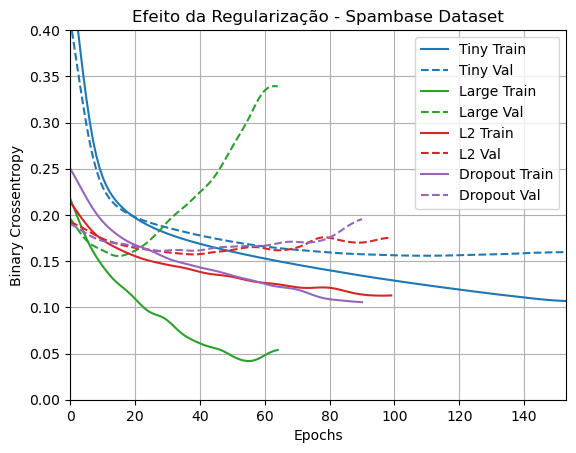

In [32]:
if plotter:
    plotter.plot(regularizer_histories_spam)
    plt.ylim([0, 0.4])
    plt.title("Efeito da Regularização - Spambase Dataset")
    plt.show()

com mais dados, o overfiting do modelo 'large' é menos impactante inicialmente, mas ainda é um problema. a perdad de validacao difere da de treinamente apos algumas epocas. novamentem tanto na regularizacao l2 quanto na dropout sao muito bem em forçar o modelo a aprender padroes mais gerais, melhoradno muito o desempenho no conjunto de validação.

# banknote authentication dataset
esse data set foi criado a partir de iumahens de notas para deerminar se sao genuinas ou falsificadas.
4 features numericas e 1372 amostras

In [33]:
caminho = r'C:\Users\marco\OneDrive\Documentos\Faculdade 2025.1\Redes Neutais\dl-2025-1\tasks\task-08-overfit and underfit\data_banknote_authentication.txt'

banknote_df = pd.read_csv(caminhho, header=None)
X = banknote_df.iloc[:, :-1].values
y = banknote_df.iloc[:,-1].values
y = y.reshape(-1,1)


In [34]:
if X is not None:
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    
    BATCH_SIZE = 64
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train)).batch(BATCH_SIZE)
    validate_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

    FEATURES = X_train.shape[1]

In [35]:
if X is not None:
    # Treinamento dos modelos de diferentes tamanhos
    size_histories_banknote = {}
    tiny_model_banknote = tf.keras.Sequential([
        layers.Dense(16, activation='elu', input_shape=(FEATURES,)),
        layers.Dense(1)
    ]) # Definição idêntica
    large_model_banknote = tf.keras.Sequential([
        layers.Dense(512, activation='elu', input_shape=(FEATURES,)),
        layers.Dense(512, activation='elu'),
        layers.Dense(512, activation='elu'),
        layers.Dense(1)
    ]) # Definição idêntica
    
    size_histories_banknote['Tiny'] = compile_and_fit(tiny_model_banknote, 'banknote/sizes/Tiny')
    size_histories_banknote['Large'] = compile_and_fit(large_model_banknote, 'banknote/sizes/Large')


c:\Users\marco\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch: 0, accuracy:0.6538,  binary_crossentropy:0.6381,  loss:0.6381,  val_accuracy:0.7872,  val_binary_crossentropy:0.4566,  val_loss:0.4566,  
....................................................................................................
Epoch: 100, accuracy:0.9565,  binary_crossentropy:0.1103,  loss:0.1103,  val_accuracy:0.9457,  val_binary_crossentropy:0.1519,  val_loss:0.1519,  
..................................
Epoch: 0, accuracy:0.9000,  binary_crossentropy:0.2786,  loss:0.2786,  val_accuracy:0.8990,  val_binary_crossentropy:0.2591,  val_loss:0.2591,  
.................................................................

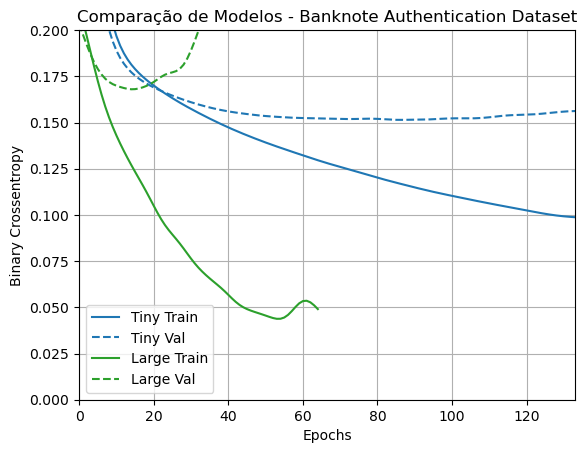

In [36]:
if plotter:
    plotter.plot(size_histories_banknote)
    plt.ylim([0, 0.2])
    plt.title("Comparação de Modelos - Banknote Authentication Dataset")
    plt.show()

In [ ]:
regularizer_histories_banknote = {}
regularizer_histories_banknote['Tiny'] = size_histories_banknote['Tiny']
regularizer_histories_banknote['Large'] = size_histories_banknote['Large']
    
l2_model_banknote = tf.keras.Sequential([
    layers.Dense(512, activation='elu', kernel_regularizer = regularizers.l2(0.001), input_shape=(FEATURES,)),
    layers.Dense(512, activation='elu', kernel_regularizer = regularizers.l2(0.001)),
    layers.Dense(512, activation='elu', kernel_regularizer = regularizers.l2(0.001)),
    layers.Dense(1)
])
dropout_model_banknote = tf.keras.Sequential([
    layers.Dense(512, activation='elu', input_shape=(FEATURES,)),
    layers.Dropout(0.5),
    layers.Dense(512, activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(512, activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(1)
])

regularizer_histories_banknote['L2'] = compile_and_fit(l2_model_banknote, "banknote/regularizers/L2")
regularizer_histories_banknote['Dropout'] = compile_and_fit(dropout_model_banknote, "banknote/regularizers/Dropout")
    

c:\Users\marco\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch: 0, accuracy:0.9008,  binary_crossentropy:0.2728,  loss:1.2252,  val_accuracy:0.9034,  val_binary_crossentropy:0.2170,  val_loss:0.9930,  
.............................................................................................
Epoch: 0, accuracy:0.8864,  binary_crossentropy:0.3197,  loss:0.3197,  val_accuracy:0.9153,  val_binary_crossentropy:0.2087,  val_loss:0.2087,  
.......................................................................................

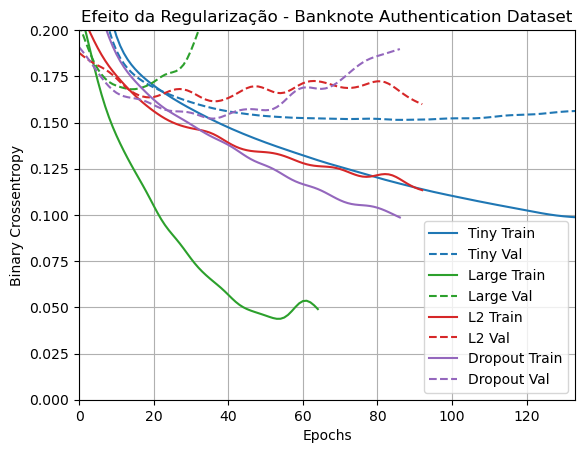

In [38]:
if plotter:
    plotter.plot(regularizer_histories_banknote)
    plt.ylim([0, 0.2])
    plt.title("Efeito da Regularização - Banknote Authentication Dataset")
    plt.show()

O padrao de overfitting do moledo 'large' continua notavel. a regularizacao l2 e dropout novamente se provam essesciais apara controlar o modelo, resultando em um desempenho de validacao muito superior.


as tecnicas de regularizacao foram universalmente eficazes. elas restrigiram a complexidade dos modelos grandes, forçando eles a aprender padroes mais robustos e reduzindo muito o overfiting. em todos os modelos que testei, um modelo grande e regularizado se mostra competivibo com o medelo menor